# SHAP Values for Model Interpretation

## Overview

SHAP (SHapley Additive exPlanations) assigns each feature a contribution to each prediction, grounded in cooperative game theory. The SHAP value for feature $j$ on observation $i$ is its average marginal contribution across all possible feature orderings.

**Guarantees (axioms):**
- **Efficiency:** SHAP values sum to prediction − baseline
- **Symmetry:** identical features get identical SHAP values
- **Dummy:** a feature with no effect gets SHAP = 0
- **Additivity:** SHAP values combine correctly across additive models

**SHAP plot types:**

| Plot | Level | Shows |
|---|---|---|
| **Bar (mean \|SHAP\|)** | Global | Overall feature importance |
| **Beeswarm** | Global | Importance + direction + distribution |
| **Dependence** | Global | Marginal effect + interaction |
| **Waterfall** | Local | How each feature drives one prediction |
| **Force** | Local | Compact push/pull representation |

Note: this notebook covers tree-based models via `shapviz`. For a shorter intro in the context of classification, see `10_classification/shap_explainability_R.ipynb`.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(xgboost)
library(shapviz)       # shapviz(), sv_importance(), sv_dependence(), sv_waterfall()
library(patchwork)

set.seed(42)

n <- 600
shap_data <- tibble(
  nitrate      = runif(n, 1, 10),
  water_qual   = runif(n, 2, 9),
  elevation    = rnorm(n, 200, 80),
  slope_pct    = abs(rnorm(n, 10, 5)),
  distance_km  = rexp(n, 0.5),
  richness     = round(
    28 - 2.2*nitrate + 1.5*water_qual +
    0.015*elevation - 0.3*slope_pct - 0.8*distance_km +
    rnorm(n, 0, 3)
  )
)

feat_cols <- c("nitrate","water_qual","elevation","slope_pct","distance_km")
X <- as.matrix(shap_data[, feat_cols])
y <- shap_data$richness

# Train/test split
idx_train  <- sample(n, n*0.8)
dtrain     <- xgboost::xgb.DMatrix(X[idx_train,], label=y[idx_train])
dtest      <- xgboost::xgb.DMatrix(X[-idx_train,], label=y[-idx_train])

xgb_fit <- xgboost::xgb.train(
  params = list(objective="reg:squarederror", eta=0.05,
                max_depth=4, subsample=0.8, colsample_bytree=0.8),
  data   = dtrain,
  nrounds= 300,
  watchlist = list(val=dtest),
  early_stopping_rounds = 30,
  verbose = 0
)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'xgboost' was built under R version 4.4.3"
Warning message:
"package 'shapviz' was built under R version 4.

---

## Computing Tree SHAP

In [2]:
# Use held-out test data for SHAP — reflects generalisation, not training fit
X_explain <- X[-idx_train, ]

shap_obj <- shapviz::shapviz(xgb_fit, X_pred=X_explain)

# Verify additivity: SHAP values + baseline = prediction
shap_vals  <- shapviz::get_shap_values(shap_obj)
baseline   <- shapviz::get_baseline(shap_obj)
preds      <- predict(xgb_fit, dtest)

reconstruction_error <- max(abs(
  rowSums(shap_vals) + baseline - preds
))
cat(sprintf("Max reconstruction error: %.6f (should be near 0)\n",
            reconstruction_error))
cat(sprintf("Baseline (mean training prediction): %.2f\n", baseline))

Max reconstruction error: 0.000026 (should be near 0)
Baseline (mean training prediction): 22.94


---

## Global Interpretation

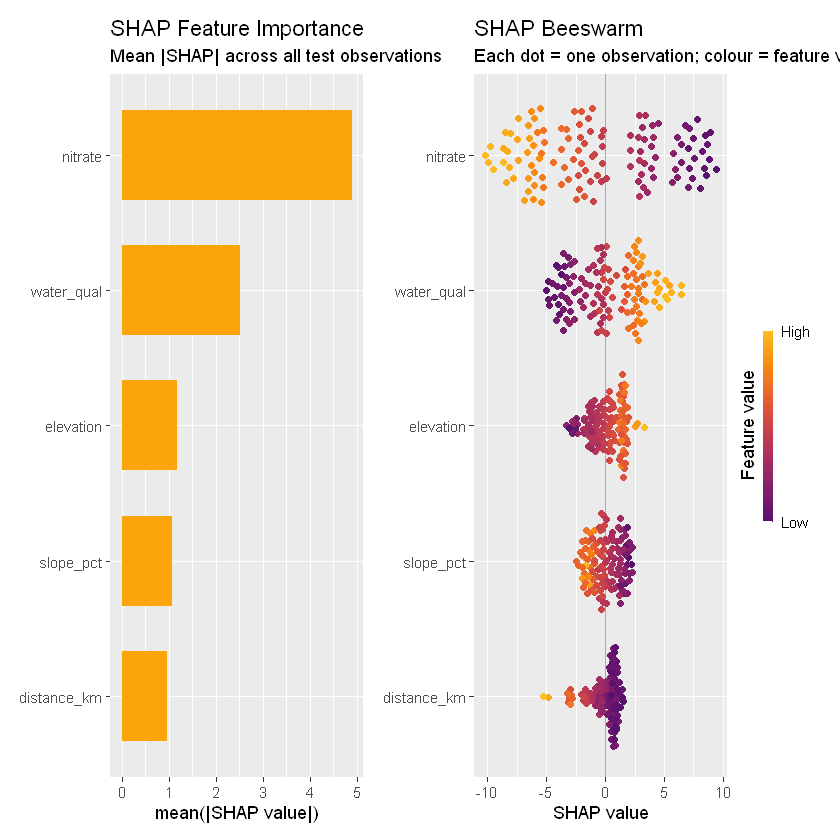

In [3]:
# ── Beeswarm: importance + direction + distribution ───────────────────────────
# Each point = one observation
# Position on x-axis = SHAP value (impact on prediction)
# Colour = original feature value (red=high, blue=low)
# Features sorted by mean |SHAP| (importance)
p_bee <- shapviz::sv_importance(shap_obj, kind="beeswarm") +
  labs(title="SHAP Beeswarm",
       subtitle="Each dot = one observation; colour = feature value; x = prediction impact")

# ── Bar: mean |SHAP| (classic importance) ─────────────────────────────────────
p_bar <- shapviz::sv_importance(shap_obj, kind="bar") +
  labs(title="SHAP Feature Importance",
       subtitle="Mean |SHAP| across all test observations")

(p_bar | p_bee)

---

## SHAP Dependence Plots

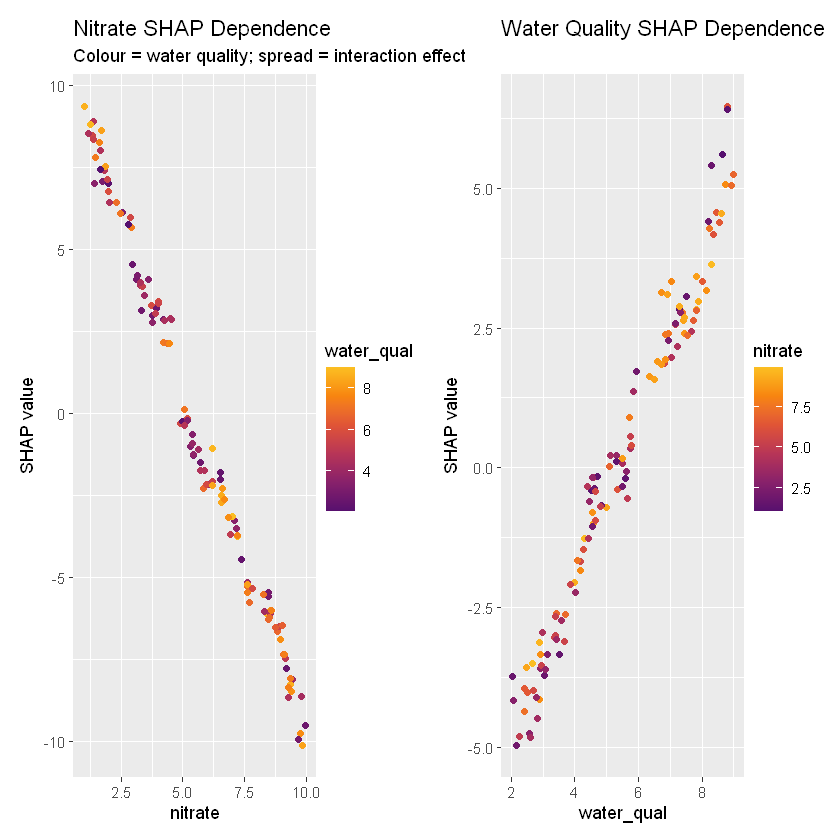

In [4]:
# Dependence plot: SHAP value vs. feature value
# Shows the marginal effect of each feature on predictions
# colour_var: colours by a second feature to reveal interactions

p_nit  <- shapviz::sv_dependence(shap_obj, v="nitrate",
                                  color_var="water_qual") +
  labs(title="Nitrate SHAP Dependence",
       subtitle="Colour = water quality; spread = interaction effect")

p_wq   <- shapviz::sv_dependence(shap_obj, v="water_qual",
                                  color_var="nitrate") +
  labs(title="Water Quality SHAP Dependence")

(p_nit | p_wq)

---

## Local Interpretation: Single Observations

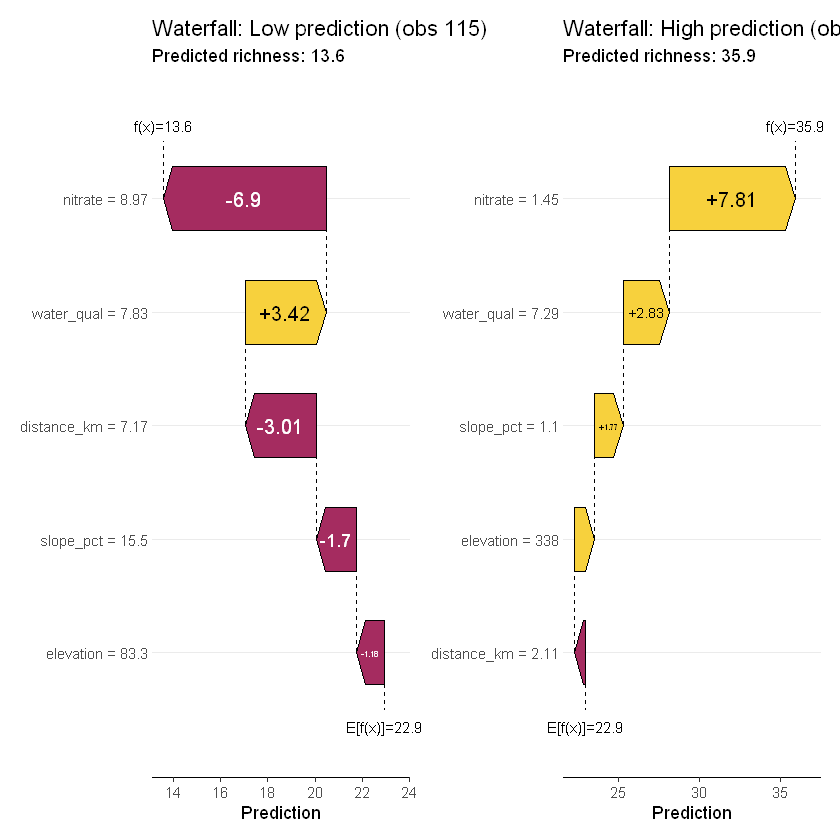

In [5]:
# Waterfall: how each feature drove the prediction for one observation
# Starting from baseline → each bar adds or subtracts → final prediction

# Find a high-richness and a low-richness prediction for contrast
pred_order <- order(preds)
low_idx    <- pred_order[5]
high_idx   <- pred_order[length(pred_order)-4]

p_wf_low  <- shapviz::sv_waterfall(shap_obj, row_id=low_idx) +
  labs(title=sprintf("Waterfall: Low prediction (obs %d)", low_idx),
       subtitle=sprintf("Predicted richness: %.1f", preds[low_idx]))

p_wf_high <- shapviz::sv_waterfall(shap_obj, row_id=high_idx) +
  labs(title=sprintf("Waterfall: High prediction (obs %d)", high_idx),
       subtitle=sprintf("Predicted richness: %.1f", preds[high_idx]))

(p_wf_low | p_wf_high)

---

## Common Pitfalls

**1. Computing SHAP on training data**  
SHAP values computed on training data reflect how the model fits those specific observations — including overfitting. Always compute SHAP on held-out test data to understand generalisation behaviour. The difference between training-set and test-set SHAP importance rankings can reveal features the model has overfit.

**2. Interpreting SHAP as causal effect**  
SHAP values explain the model's predictions, not the data-generating process. A high SHAP for nitrate means the model uses nitrate strongly — not that nitrate causally drives richness in the real world. The model may be using nitrate as a proxy for an unmeasured confounder.

**3. Confusing SHAP scale with original feature scale**  
For XGBoost regression with objective `reg:squarederror`, SHAP values are in the units of the response (species richness). For classification with `binary:logistic`, SHAP values are in log-odds — not probability. Always check the model objective before interpreting SHAP magnitude.

**4. Using gain-based importance instead of SHAP for final reporting**  
Gain importance is biased toward features with many split points (continuous variables, high-cardinality categoricals). SHAP importance is consistent and accounts for interactions. For any publication or stakeholder report, use SHAP mean |SHAP| rather than gain importance.

**5. Treating the beeswarm as a regression plot**  
The beeswarm x-axis shows SHAP values (prediction impact), not the response variable. A positive SHAP for observation i means that feature increases prediction_i above baseline — not that the feature predicts a high response absolutely.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*